In [45]:
import h5py
import numpy as np
from matplotlib import pyplot as plt

In [82]:
surface_ids = np.load('surface_ids.npy')
bin_areas = np.load('bin_areas.npy')
numb_bands = bin_areas.shape[0]
bins_per_band = bin_areas.shape[1]
num_bins = len(bin_areas.flatten())
print(num_bins)
print(numb_bands, bins_per_band)

6745
71 95


In [10]:
with h5py.File('surface_source.h5') as surface_source:
    
    source_bank = surface_source['source_bank']
    print(source_bank)

<HDF5 dataset "source_bank": shape (1000000,), type "|V104">


In [14]:
f =  h5py.File("surface_source.h5", "r")

In [15]:
list[f.keys()]

list[<KeysViewHDF5 ['source_bank']>]

In [19]:
surface_crossings = f['source_bank']["surf_id"]

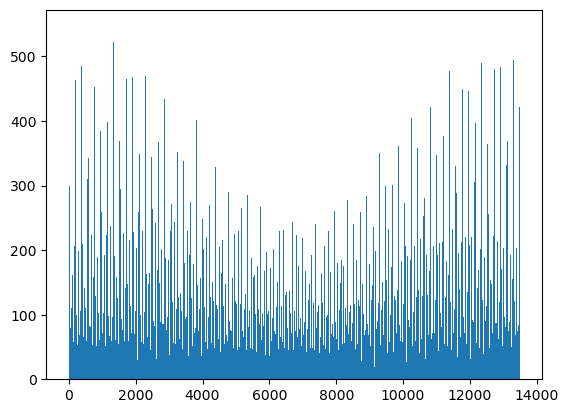

In [115]:
crossings_per_bin, bin_edges, _ = plt.hist(surface_crossings, bins=np.arange(1,2*num_bins+3, 2))

In [116]:
bin_edges[0:10]

array([ 1.,  3.,  5.,  7.,  9., 11., 13., 15., 17., 19.])

In [117]:
bin_edges[-10:]

array([13473., 13475., 13477., 13479., 13481., 13483., 13485., 13487.,
       13489., 13491.])

In [118]:
bin_edges[-1]

13491.0

In [111]:
len(bin_edges)

6745

In [126]:
nwl_matrix = crossings_per_bin.reshape(bin_areas.shape)
nwl_matrix  = nwl_matrix/(bin_areas/1e4)

In [127]:
phi_pts = np.linspace(0, 90, 71)
theta_pts = np.linspace(0,360, 95)

Text(0, 0.5, 'Poloidal Angle (degrees)')

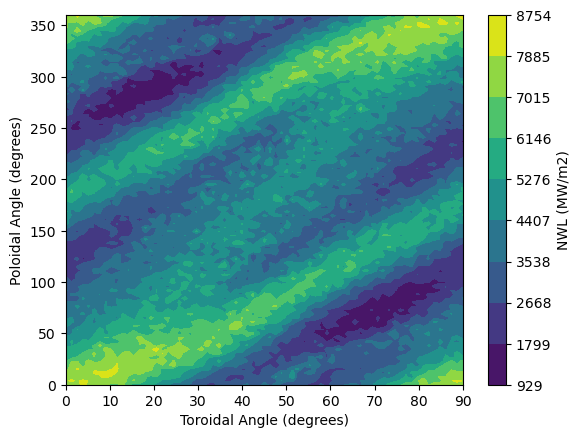

In [128]:
levels = np.linspace(np.min(nwl_matrix), np.max(nwl_matrix), 10)
cf = plt.contourf(phi_pts, theta_pts, nwl_matrix.T, levels = levels)
cbar = plt.colorbar(cf)
cbar.ax.set_ylabel("NWL (MW/m2)")
plt.xlabel("Toroidal Angle (degrees)")
plt.ylabel("Poloidal Angle (degrees)")